### 2.3. Fundamentals of Visualization - part 1 - Matplotlib

#### importing libraries, files and doing some data wrangling:

In [5]:
#importing libraries
import matplotlib
matplotlib.__version__
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from datetime import datetime as dt

In [6]:
#upload data file
df = pd.read_parquet('/kaggle/input/notebooks/danielabranca/citybike-merge-wrangle/citibike_merged_2022.parquet')

In [7]:
df.columns

Index(['rideable_type', 'started_at', 'ended_at', 'start_station_name',
       'end_station_name', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'start_date', 'date', 'tavg', 'tmax', 'tmin'],
      dtype='object')

In [8]:
df.head()

,rideable_type,started_at,ended_at,start_station_name,end_station_name,start_lat,start_lng,end_lat,end_lng,member_casual,start_date,date,tavg,tmax,tmin
0,classic_bike,2022-01-13 21:36:47.689,2022-01-13 21:46:02.024,5 Ave & E 63 St,Broadway & W 51 St,40.766368,-73.971518,40.762288,-73.983362,member,2022-01-13,2022-01-13,4.5,8.0,1.0
1,classic_bike,2022-01-16 17:56:23.889,2022-01-16 18:03:50.269,Grand Army Plaza & Plaza St West,Bedford Ave & Montgomery St,40.672968,-73.970880,40.665816,-73.956934,member,2022-01-16,2022-01-16,-4.0,4.0,-12.0
2,electric_bike,2022-01-18 07:10:04.799,2022-01-18 07:20:54.450,W 20 St & 10 Ave,Broadway & W 51 St,40.745686,-74.005141,40.762288,-73.983362,member,2022-01-18,2022-01-18,1.0,3.0,-1.0
3,classic_bike,2022-01-22 12:10:10.225,2022-01-22 12:20:06.899,W 54 St & 9 Ave,10 Ave & W 28 St,40.765849,-73.986905,40.750664,-74.001768,member,2022-01-22,2022-01-22,-5.5,-1.0,-10.0
4,classic_bike,2022-01-08 16:35:16.497,2022-01-08 16:45:33.279,Sharon St & Olive St,Driggs Ave & Lorimer St,40.715353,-73.938560,40.721791,-73.950415,casual,2022-01-08,2022-01-08,-2.5,0.0,-5.0


##### The *name* and *station* for this dataset are:
- *LAGUARDIA AIRPORT, NY US*
- *USW00014732*

In [9]:
df.dtypes

rideable_type                 object
started_at            datetime64[ns]
ended_at              datetime64[ns]
start_station_name            object
end_station_name              object
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                 object
start_date            datetime64[ns]
date                  datetime64[ns]
tavg                         float64
tmax                         float64
tmin                         float64
dtype: object

#### Plotting with pandas

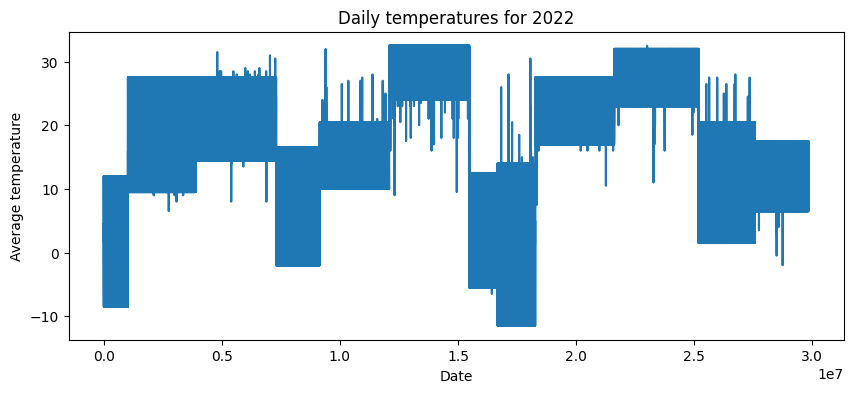

In [10]:
#plotting temperature in a line chart:
plt.figure(figsize=(10,4))
plt.title('Daily temperatures for 2022')
plt.plot(df['tavg'])

plt.xlabel('Date')
plt.ylabel('Average temperature')

plt.show()

- Many things did not work here:
- The line chart shows colored blocks and the date is not determined, it's potence numbers.
- It's best to set 'date' as an index and sort it on the process, and then see what happens.

In [11]:
#sorting the dataframe by date, by setting it as index:
df_temp = df.set_index('date').sort_index()
df_temp.head()

,rideable_type,started_at,ended_at,start_station_name,end_station_name,start_lat,start_lng,end_lat,end_lng,member_casual,start_date,tavg,tmax,tmin
date,,,,,,,,,,,,,,
2022-01-01,classic_bike,2022-01-01 15:02:39.345,2022-01-01 15:21:30.676,Queens Plaza North & Crescent St,E 60 St & York Ave,40.751102,-73.940737,40.759107,-73.959223,casual,2022-01-01,12.0,14.0,10.0
2022-01-01,electric_bike,2022-01-01 04:36:41.780,2022-01-02 05:36:32.904,Washington St & Gansevoort St,None,40.739323,-74.008119,NaN,NaN,casual,2022-01-01,12.0,14.0,10.0
2022-01-01,classic_bike,2022-01-01 16:15:24.466,2022-01-01 16:57:00.973,State St & Smith St,Dock St & Front St,40.689170,-73.988600,40.702709,-73.992530,casual,2022-01-01,12.0,14.0,10.0
2022-01-01,classic_bike,2022-01-01 16:29:27.081,2022-01-01 16:31:56.704,E 41 St & Madison Ave (SW corner),W 44 St & 5 Ave,40.752165,-73.979922,40.755003,-73.980144,member,2022-01-01,12.0,14.0,10.0
2022-01-01,electric_bike,2022-01-01 14:57:12.508,2022-01-01 15:08:51.448,E 13 St & 2 Ave,Franklin St & W Broadway,40.731539,-73.985302,40.719116,-74.006667,member,2022-01-01,12.0,14.0,10.0


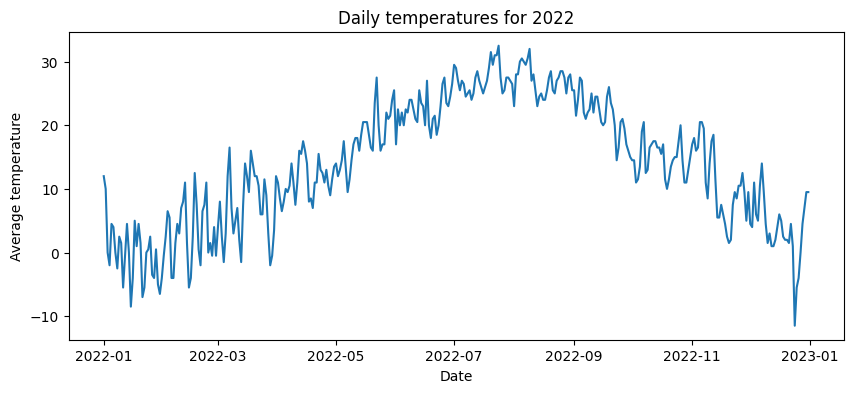

In [12]:
plt.figure(figsize=(10,4))
plt.title('Daily temperatures for 2022')
plt.plot(df_temp['tavg'])

plt.xlabel('Date')
plt.ylabel('Average temperature')

plt.show()

**Much better!** 

#### Dual axis plot: object oriented approach:
- Creating a line chart of bike trip counts and temperatures plotted on a dual axis.

**Let's try to aggregate firstly the dates, since it's a dataset of almost 30*10^6 columns, and depart from there.**

- 1 line = 1 trip

Let's aggregate data in that sense, by preparing two smaller data frames and then merging them together.

In [13]:
#aggregating data by date and using 'rideable_type' column to count daily rides:
daily_rides = (
    df.groupby('date')
      .agg(daily_bike_rides=('rideable_type', 'count'))
      .reset_index()
)
daily_rides.head()

,date,daily_bike_rides
0,2022-01-01,20428
1,2022-01-02,43009
2,2022-01-03,33189
3,2022-01-04,36842
4,2022-01-05,34230


In [14]:
#aggregating data by date and using 'tavg' column to know the avg temp for each day: 
daily_weather = (
    df.groupby('date', as_index=False)['tavg']
      .mean()
)
daily_weather.head()

,date,tavg
0,2022-01-01,12.0
1,2022-01-02,10.0
2,2022-01-03,0.0
3,2022-01-04,-2.0
4,2022-01-05,4.5


In [15]:
#merging:
df_final = daily_rides.merge(daily_weather, on='date', how='inner')
df_final.head()

,date,daily_bike_rides,tavg
0,2022-01-01,20428,12.0
1,2022-01-02,43009,10.0
2,2022-01-03,33189,0.0
3,2022-01-04,36842,-2.0
4,2022-01-05,34230,4.5


In [16]:
df_final.shape

(365, 3)

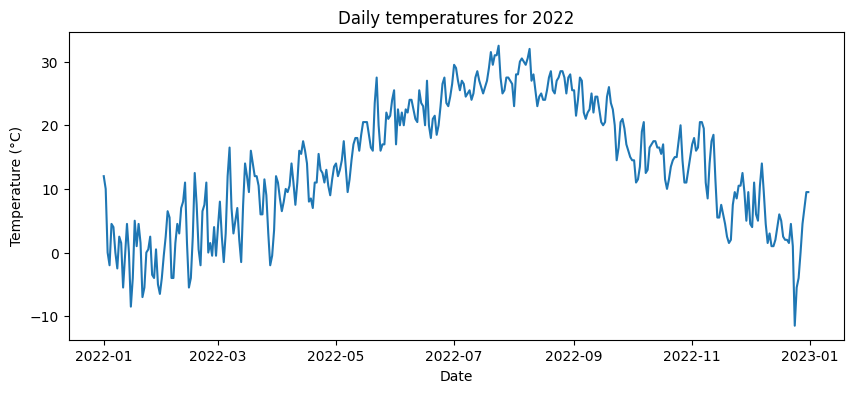

In [17]:
#### the same plot as before, which I struggled doing:
plt.figure(figsize=(10,4))
plt.title('Daily temperatures for 2022')
plt.plot(df_final['date'], df_final['tavg'])
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.show()

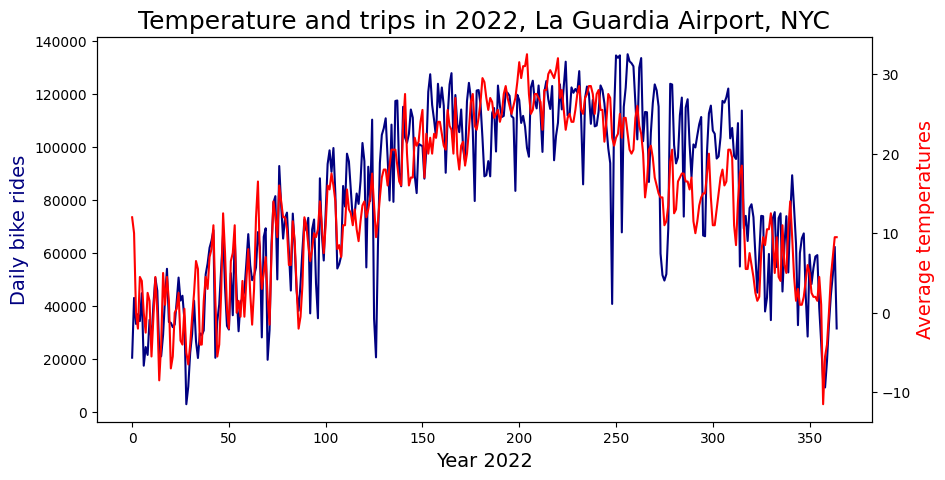

In [18]:
#creating a figure and axis objects with subplots()
fig,ax = plt.subplots(figsize=(10,5))

#making a plot of the bike rides:
ax.plot(df_final['daily_bike_rides'], color = 'navy')
ax.set_xlabel("Year 2022", fontsize = 14)
ax.set_ylabel("Daily bike rides",color = "navy", fontsize = 14)

#creating a dual axis
ax2 = ax.twinx()

#making a plot with the temperatures using 2nd axis object
ax2.plot(df_final['tavg'], color = 'red')
ax2.set_ylabel("Average temperatures", color = "red",fontsize=14)

plt.title('Temperature and trips in 2022, La Guardia Airport, NYC', fontsize = 18)
plt.show()


##### no x axis configured, it gets automatically defined. Lets make it look better by defining it:

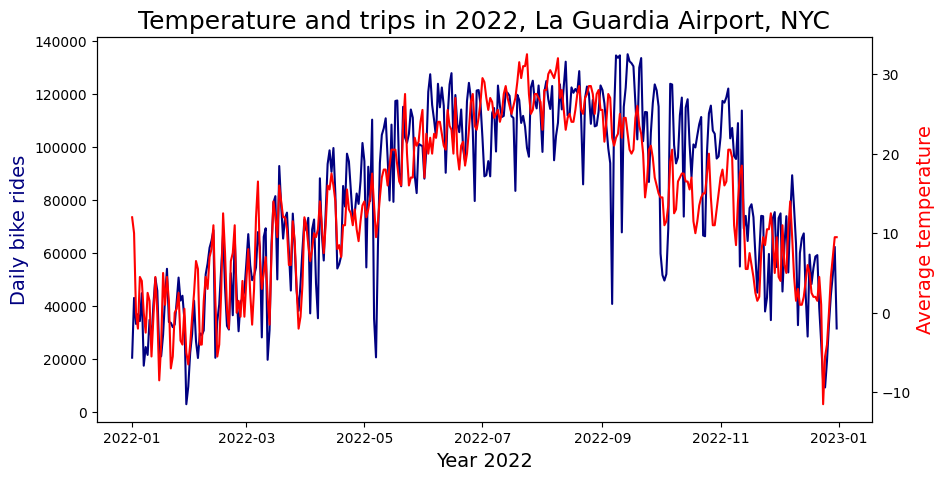

In [19]:
#creating a figure and axis objects with subplots()
fig,ax = plt.subplots(figsize=(10,5))

#making a plot of the bike rides:
ax.plot(df_final['date'], df_final['daily_bike_rides'], color = 'navy')
ax.set_xlabel("Year 2022", fontsize = 14)
ax.set_ylabel("Daily bike rides",color = "navy", fontsize = 14)

#creating a dual axis
ax2 = ax.twinx()

#making a plot with the temperatures using 2nd axis object
ax2.plot(df_final['date'], df_final['tavg'], color = 'red')
ax2.set_ylabel("Average temperature", color = "red",fontsize=14)

plt.title('Temperature and trips in 2022, La Guardia Airport, NYC', fontsize = 18)
plt.show()


##### Let's embelish the x axis labels:

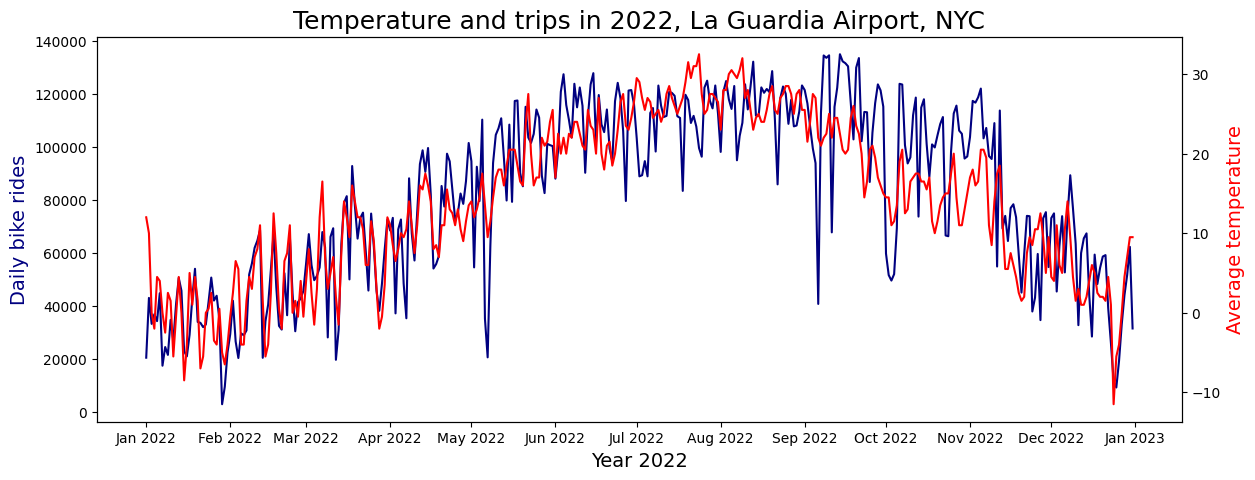

In [20]:
import matplotlib.dates as mdates #lets embelish the x axis labels:

#creating a figure and axis objects with subplots()
fig,ax = plt.subplots(figsize=(14,5))

#making a plot of the bike rides:
ax.plot(df_final['date'], df_final['daily_bike_rides'], color = 'navy')
ax.set_xlabel("Year 2022", fontsize = 14)
ax.set_ylabel("Daily bike rides",color = "navy", fontsize = 14)

#creating a dual axis
ax2 = ax.twinx()

#making a plot with the temperatures using 2nd axis object
ax2.plot(df_final['date'], df_final['tavg'], color = 'red')
ax2.set_ylabel("Average temperature", color = "red",fontsize=14)

#here's the difference:
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.title('Temperature and trips in 2022, La Guardia Airport, NYC', fontsize = 18)
plt.show()


#### Dual-axis line chart: monthly trips and average temperature

This chart was created using Matplotlib's **object-oriented (OO) paradigm**, 
which gives more precise control over the figure and its elements compared 
to the simpler `plt.` interface.

A single `fig` and `ax1` were created with `plt.subplots()`. A second axis 
`ax2` was then derived from `ax1` using `ax1.twinx()`, which creates a second 
Y-axis sharing the same X-axis. This allows two variables with different scales 
— number of trips (in millions) and temperature (°C) — to be plotted on the 
same chart without distorting either scale.

Each axis was plotted and labelled independently, and a combined legend was 
created by merging the handles from both axes.

In [21]:
#saving the plot as a file
fig.savefig('tripstemperatures_dualaxis.jpg',
            format='jpeg',
            dpi=100,
            bbox_inches='tight')

### Bonus Tasks:

- **Create a histogram of the variable “tripduration” using matplotlib. Add a curve following the bins.**

- ``I have to derive a column, 'tripduration', from 'started_at' and 'ended_at'.``

- **Create a figure with two axes that represent different plots: one of the plots is a bar chart with the variable “usertype,” and the other one is a pie chart illustrating the variable “gender."**

- ``There's no usertype or gender. There's rideable_type and member_casual. I can do something with that.``

In [22]:
#deriving tripduration in minutes
df_temp['tripduration'] = (df_temp['ended_at'] - df_temp['started_at']).dt.total_seconds() / 60

In [23]:
#let's see what the descriptive statistics is saying:
print(df_temp['tripduration'].describe())

count    2.983817e+07
mean     1.820962e+01
std      2.614485e+02
min     -5.728892e+01
25%      5.796733e+00
50%      1.016200e+01
75%      1.799900e+01
max      4.044810e+05
Name: tripduration, dtype: float64


In [24]:
#easier to understand these numbers:
df_temp['tripduration'].describe().round(2)

count    29838166.00
mean           18.21
std           261.45
min           -57.29
25%             5.80
50%            10.16
75%            18.00
max        404481.01
Name: tripduration, dtype: float64

**There's a discrepancy in the minimum and maximum values, which are negative and corresponding to 280 days, respectively. Let's solve this:**
- first question: does the data assume a normal distribution?

In [25]:
print(f"Skewness: {df_temp['tripduration'].skew():.2f}")

Skewness: 592.18


**the data talks: a large positive skew means the distribution is far from being normal, with many outliers for longer trips. Lets try to plot this so we can understand it visually:**

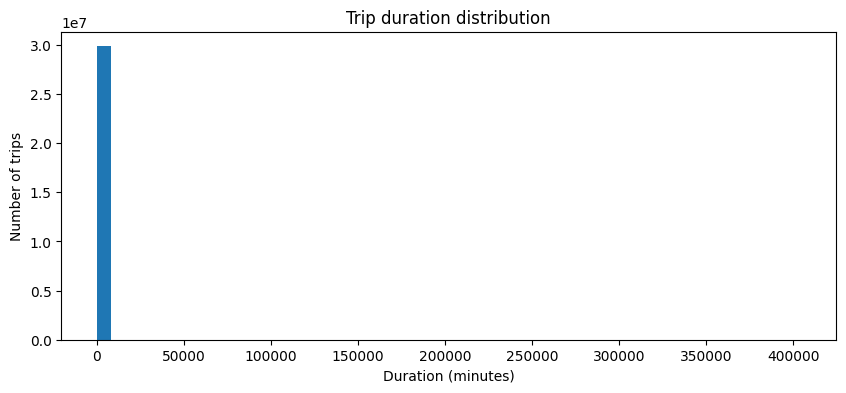

In [26]:
#the histogram:
plt.figure(figsize=(10,4))
plt.title('Trip duration distribution')
plt.hist(df_temp['tripduration'], bins=50)
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of trips')
plt.show()

In [27]:
#Let's discover the interquartile range and from there define a limit for the long trip outliers and remove the negative ones:
Q1 = df_temp['tripduration'].quantile(0.25)
Q3 = df_temp['tripduration'].quantile(0.75)
IQR = Q3 - Q1

limit_max = Q3 + 1.5 * IQR

df_temp3 = df_temp[(df_temp['tripduration'] > 0) & (df_temp['tripduration'] <= limit_max)]

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Maximum limit: {limit_max:.2f}")

Q1: 5.80
Q3: 18.00
IQR: 12.20
Maximum limit: 36.30


Wow, so many outliers!!! Let's see how many were filtered:

In [28]:
removed = len(df_temp) - len(df_temp3)
print(f"Filtered values: {removed}")
print(f"Removed percentage: {removed/len(df_temp)*100:.2f}%")

Filtered values: 1883972
Removed percentage: 6.31%


The value is a bit higher than normally acceptable (5%) but I'll leave it like this and proceed. 

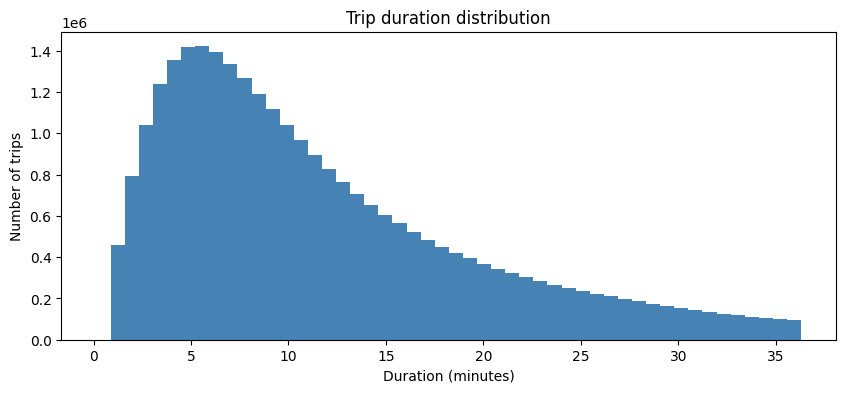

In [29]:
#the histogram plot:
plt.figure(figsize=(10,4))
plt.hist(df_temp3['tripduration'], bins=50, color='steelblue')
plt.title('Trip duration distribution')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of trips')
plt.show()

Looking interesting and beautiful. 
- let's add a curve to it and make it look more informative:

````python
#more professionally looking plot:

from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(10,4))

#histogram
ax.hist(df_temp3['tripduration'], bins=50, density=True, alpha=0.7, color='steelblue')

#KDE curve
kde = gaussian_kde(df_temp3['tripduration'])
x = np.linspace(df_temp3['tripduration'].min(), df_temp3['tripduration'].max(), 1000)
ax.plot(x, kde(x), color='red', linewidth=2)

ax.set_title('Trip duration distribution')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Density')
plt.show()

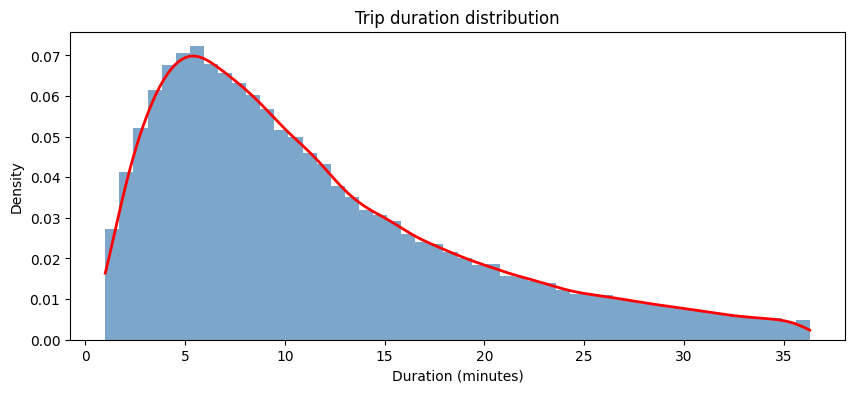

In [36]:
#kaggle doesn't compute all of these rows of data properly. Let's sample it and see what happens:

#taking a sample of 100,000 rows
sample = df_temp3['tripduration'].sample(100000, random_state=42)

fig, ax = plt.subplots(figsize=(10,4))

ax.hist(sample, bins=50, density=True, alpha=0.7, color='steelblue')

kde = gaussian_kde(sample)
x = np.linspace(sample.min(), sample.max(), 1000)
ax.plot(x, kde(x), color='red', linewidth=2)

ax.set_title('Trip duration distribution')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Density')
plt.show()

In [37]:
#saving the plot as a file
fig.savefig('tripduration_histogram.jpg',
            format='jpeg',
            dpi=100,
            bbox_inches='tight')

In [31]:
#easier to understand these numbers:
df_temp3['tripduration'].describe().round(2)

count    27954194.00
mean           11.67
std             7.95
min             0.15
25%             5.56
50%             9.51
75%            15.93
max            36.30
Name: tripduration, dtype: float64

### Let's attempt the figure with two plots now:

In [32]:
print(df_temp3['rideable_type'].value_counts())
print(df_temp3['member_casual'].value_counts())

rideable_type
classic_bike     17009100
electric_bike    10945094
Name: count, dtype: int64
member_casual
member    22248684
casual     5705510
Name: count, dtype: int64


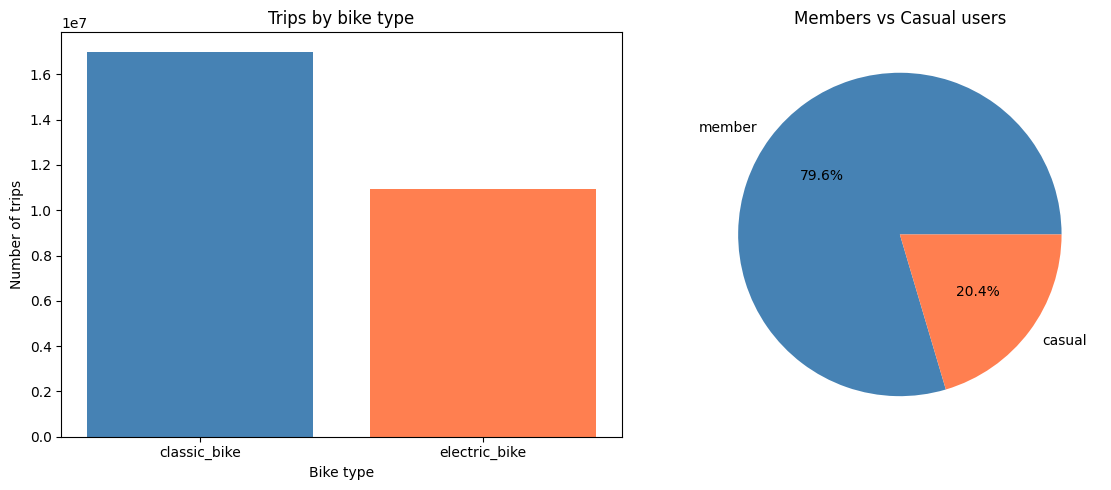

In [33]:
#the figure with the two plots:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart - rideable_type
rideable_counts = df_temp3['rideable_type'].value_counts()
ax1.bar(rideable_counts.index, rideable_counts.values, color=['steelblue', 'coral'])
ax1.set_title('Trips by bike type')
ax1.set_xlabel('Bike type')
ax1.set_ylabel('Number of trips')

# Pie chart - member_casual
member_counts = df_temp3['member_casual'].value_counts()
ax2.pie(member_counts.values, labels=member_counts.index, autopct='%1.1f%%', colors=['steelblue', 'coral'])
ax2.set_title('Members vs Casual users')

plt.tight_layout()
plt.show()

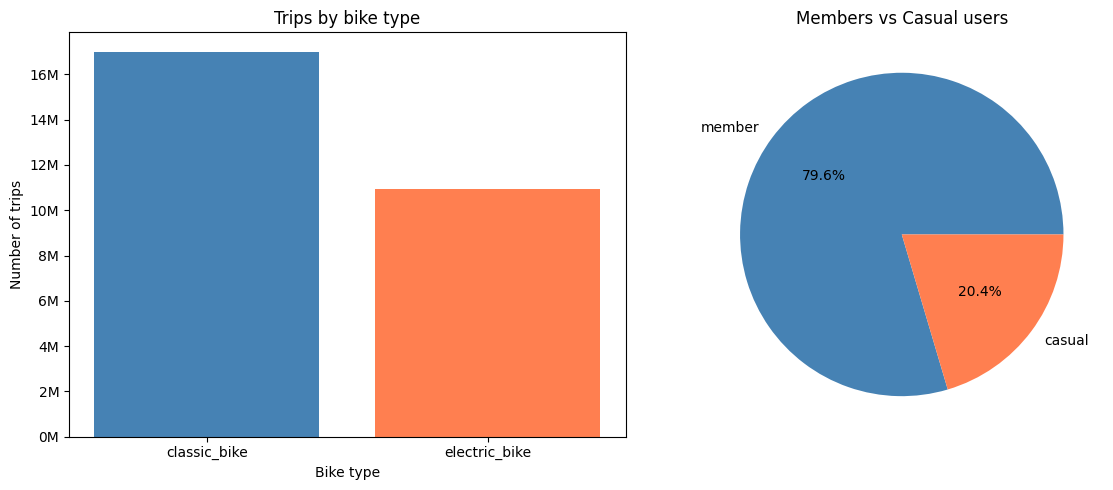

In [34]:
#the figure with the two plots, with a better y axis:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart - rideable_type
rideable_counts = df_temp3['rideable_type'].value_counts()
ax1.bar(rideable_counts.index, rideable_counts.values, color=['steelblue', 'coral'])
ax1.set_title('Trips by bike type')
ax1.set_xlabel('Bike type')
ax1.set_ylabel('Number of trips')

# Pie chart - member_casual
member_counts = df_temp3['member_casual'].value_counts()
ax2.pie(member_counts.values, labels=member_counts.index, autopct='%1.1f%%', colors=['steelblue', 'coral'])
ax2.set_title('Members vs Casual users')

ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1_000_000)}M')) #here's the line that makes the difference!
plt.tight_layout()
plt.show()

In [35]:
#saving the plot as a file
fig.savefig('biketype_riders_dualplot.jpg',
            format='jpeg',
            dpi=100,
            bbox_inches='tight')